# Figure 1I

In [1]:
# Import libraries
from tkinter.filedialog import askdirectory
from tkinter import Tk
import os
os.environ["OUTDATED_IGNORE"] = "1"
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pingouin as pg

cur_dir = Path(os.getcwd())
src_dir = cur_dir.parent.parent
os.chdir(src_dir)
from functions.scale_bars import AnchoredScaleBar, add_scalebar, plot_mean_dFF0
from functions.photom_plots import plot_heatmap, plot_mean_over_trials, make_boxplot, plot_mean_over_mice
os.chdir(cur_dir)

############################################################
DS_rate = 20 #standard sampling rate of input data
############################################################

plt.rcParams['figure.figsize'] = [9,10.5] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams.update({'font.size': 16})

In [2]:
###############################
DS = 10 #how much to downsample for plots
###############################

# Open a dialog box to select the directory to be analyzed
window = Tk()
window.wm_attributes('-topmost', 1)
window.withdraw()
Dir2 = askdirectory(parent = window)
os.chdir(Dir2 + '/')

# Load data
with open('AllTrialsData.pkl', 'rb') as f:
    AllTrials = pickle.load(f)

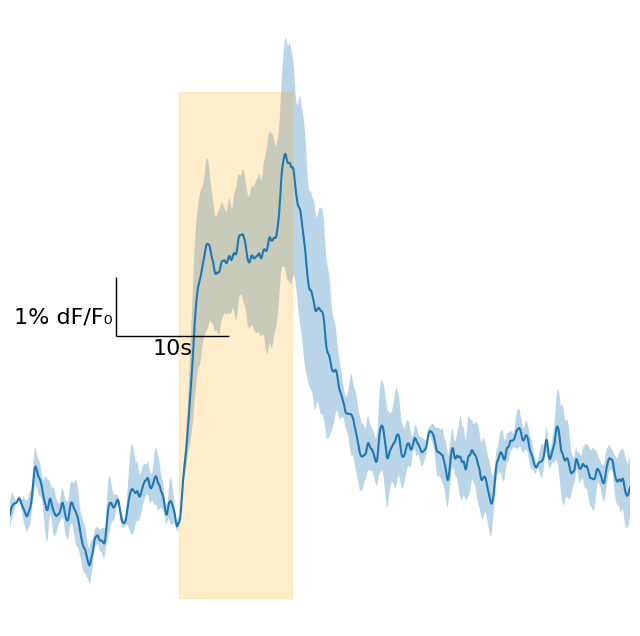

In [3]:
# Mean over all pulses
fig, ax = plt.subplots(1,1,figsize=(8,8))

ylim = [-0.015,0.07]

# Take average for each mouse, then over mice
plot_mean_dFF0(AllTrials['opto_pulse_dFF0'].groupby(by='TrialID',axis=1).mean(), ax)
ax.fill_between([0,10],[ylim[0],ylim[0]],[ylim[1],ylim[1]],
                 color='orange', alpha=0.2)
add_scalebar(ax,matchx=False,matchy=False,sizex=10,sizey=0.01,
             labelx='10s', labely=u'1% dF/F\u2080', loc='center left')

#fig.savefig('Mean dFF0 pulse.png')
#fig.savefig('Mean dFF0 pulse.pdf')